# Tweets (Text) Sentiment analysis

**Datasets used:**
1. [TweetEval](https://github.com/cardiffnlp/tweeteval)
2. [Twitter Sentiment Analysis](https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis)


## 0. Imports

In [1]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import evaluate
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Download the dataset

In [3]:
import kagglehub

In [4]:
!git clone https://github.com/cardiffnlp/tweeteval
path1 = "./tweeteval/datasets/sentiment"

Cloning into 'tweeteval'...
remote: Enumerating objects: 370, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 370 (delta 13), reused 3 (delta 1), pack-reused 354 (from 1)
Receiving objects: 100% (370/370), 8.49 MiB | 6.87 MiB/s, done.
Resolving deltas: 100% (122/122), done.


In [5]:
path2 = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")
print("Path to dataset 2:", path2)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset 2: /kaggle/input/twitter-entity-sentiment-analysis


## 2. Setup dataframes

Since the two datasets utilize different storage structures, this step performs ETL (Extract, Transform, Load) to unify them.

In [6]:
df_train = pd.DataFrame(columns=["text", "label_text", "label"])
df_test  = pd.DataFrame(columns=["text", "label_text", "label"])
df_val   = pd.DataFrame(columns=["text", "label_text", "label"])

**Dataset 1 (TweetEval):**

Labels and texts are stored in separate .txt files. The code reads these files, cleans character artifacts (like extra quotes), and maps numerical labels (0, 1, 2) to their semantic meanings (Negative, Neutral, Positive).

In [7]:
df_train_temp = pd.DataFrame(columns=["text", "label_text", "label"])
df_test_temp  = pd.DataFrame(columns=["text", "label_text", "label"])
df_val_temp   = pd.DataFrame(columns=["text", "label_text", "label"])

names = [
    ("train", df_train_temp),
    ("test",  df_test_temp),
    ("val",   df_val_temp),
]

labels_mapping = {
    "0": "Negative",
    "1": "Neutral",
    "2": "Positive"
}

for name, df in names:

    with open(path1 + "/" + name + "_labels.txt", "r") as f:
        labels = f.read().splitlines()

    with open(path1 + "/" + name + "_text.txt", "r") as f:
        texts = f.read().splitlines()

    T = []
    for t in texts:
        if t.startswith('"'):
            t = t[1:]
        if t.endswith('"'):
            t = t[:-1]
        T.append(t)

    df["text"] = T
    df["label"] = labels
    df["label_text"] = df["label"].map(labels_mapping)

display(df_train_temp.head())

df_train = pd.concat([df_train, df_train_temp], ignore_index=True)
df_test  = pd.concat([df_test, df_test_temp], ignore_index=True)
df_val   = pd.concat([df_val, df_val_temp], ignore_index=True)

,text,label_text,label
0,QT @user In the original draft of the 7th book...,Positive,2
1,Ben Smith / Smith (concussion) remains out of ...,Neutral,1
2,Sorry bout the stream last night I crashed out...,Neutral,1
3,Chase Headley's RBI double in the 8th inning o...,Neutral,1
4,@user Alciato: Bee will invest 150 million in ...,Positive,2


**Dataset 2 (Twitter Entity Sentiment):**

* Data is loaded from headerless `.csv` files. The logic assigns proper column names, maps sentiments, and drops non-essential features like `Tweet ID` or `entity`.

* Missing values (`NaN`) are handled to maintain data integrity before concatenation.

In [8]:
labels_mapping = {
    "Negative": "0",
    "Other": "1",
    "Positive": "2",
}

mapping_columns = {
    "Tweet content": "text",
    "sentiment": "label_text",
}

df_train_temp = pd.read_csv(path2 + "/twitter_training.csv", header=None, names=["Tweet ID", "entity", "sentiment", "Tweet content"])
df_val_temp   = pd.read_csv(path2 + "/twitter_validation.csv", header=None, names=["Tweet ID", "entity", "sentiment", "Tweet content"])

df_train_temp["label"] = df_train_temp["sentiment"].map(labels_mapping)
df_val_temp["label"] = df_val_temp["sentiment"].map(labels_mapping)

df_train_temp = df_train_temp.dropna(subset=["label"])
df_val_temp   = df_val_temp.dropna(subset=["label"])

df_train_temp = df_train_temp.drop(columns=["Tweet ID", "entity"])
df_val_temp   = df_val_temp.drop(columns=["Tweet ID", "entity"])

df_train_temp = df_train_temp.rename(columns=mapping_columns)
df_val_temp   = df_val_temp.rename(columns=mapping_columns)

df_train_temp = df_train_temp.dropna(subset=["text"])
df_val_temp   = df_val_temp.dropna(subset=["text"])

display(df_train_temp.head())

df_train = pd.concat([df_train, df_train_temp], ignore_index=True)
df_val   = pd.concat([df_val, df_val_temp], ignore_index=True)

,label_text,text,label
0,Positive,im getting on borderlands and i will murder yo...,2
1,Positive,I am coming to the borders and I will kill you...,2
2,Positive,im getting on borderlands and i will kill you ...,2
3,Positive,im coming on borderlands and i will murder you...,2
4,Positive,im getting on borderlands 2 and i will murder ...,2


In [9]:
del df_train_temp
del df_test_temp
del df_val_temp
del labels_mapping
del mapping_columns

## 3. Exploratory Data Analysis (EDA)

Comprehensive analysis to understand the underlying patterns and quality of the merged data.

### A. Display infos

In [10]:
print("Train samples:", len(df_train))
print("Test samples:", len(df_test))
print("Val samples:", len(df_val))
display(df_train.head())

Train samples: 88628
Test samples: 12284
Val samples: 2543


,text,label_text,label
0,QT @user In the original draft of the 7th book...,Positive,2
1,Ben Smith / Smith (concussion) remains out of ...,Neutral,1
2,Sorry bout the stream last night I crashed out...,Neutral,1
3,Chase Headley's RBI double in the 8th inning o...,Neutral,1
4,@user Alciato: Bee will invest 150 million in ...,Positive,2


### B. Data distribution

**Data Distribution:** Statistical calculation of sample counts and percentages for each class. It reveals a slight class imbalance, with "`Positive`" being the majority at ~43.4%.

In [11]:
count_df = df_train["label_text"].value_counts().reset_index()
count_df.columns = ["label_text", "count"]
count_df["percentage"] = round(count_df["count"] / count_df["count"].sum() * 100, 3)
display(count_df)

,label_text,count,percentage
0,Positive,38504,43.445
1,Negative,29451,33.230
2,Neutral,20673,23.326


### C. Sentence Length Distribution

**Text Length Analysis:** Determining the average word count (~18.9 words) to set an optimal `max_length` for tokenization, balancing computational efficiency and information retention.

In [12]:
word_count = df_train["text"].apply(lambda x: len(x.split()))
print("Average Length:", word_count.mean())

Average Length: 18.96459358216365


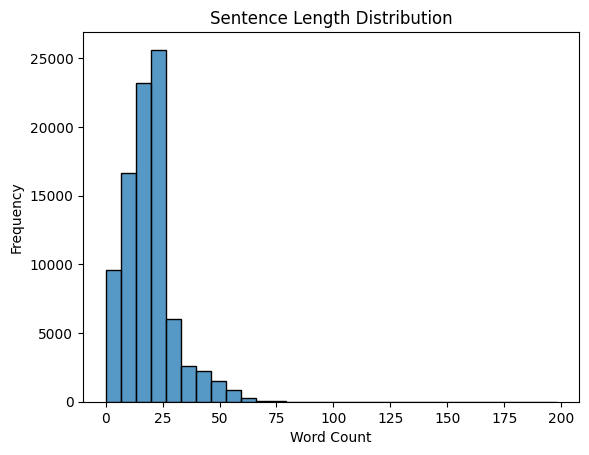

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))
sns.histplot(df_train['word_count'], bins=30)
plt.title('Sentence Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

### D. Top Unigrams for each Label

**Top Unigrams:** Extracting the most frequent single words per label to identify linguistic features unique to each sentiment.

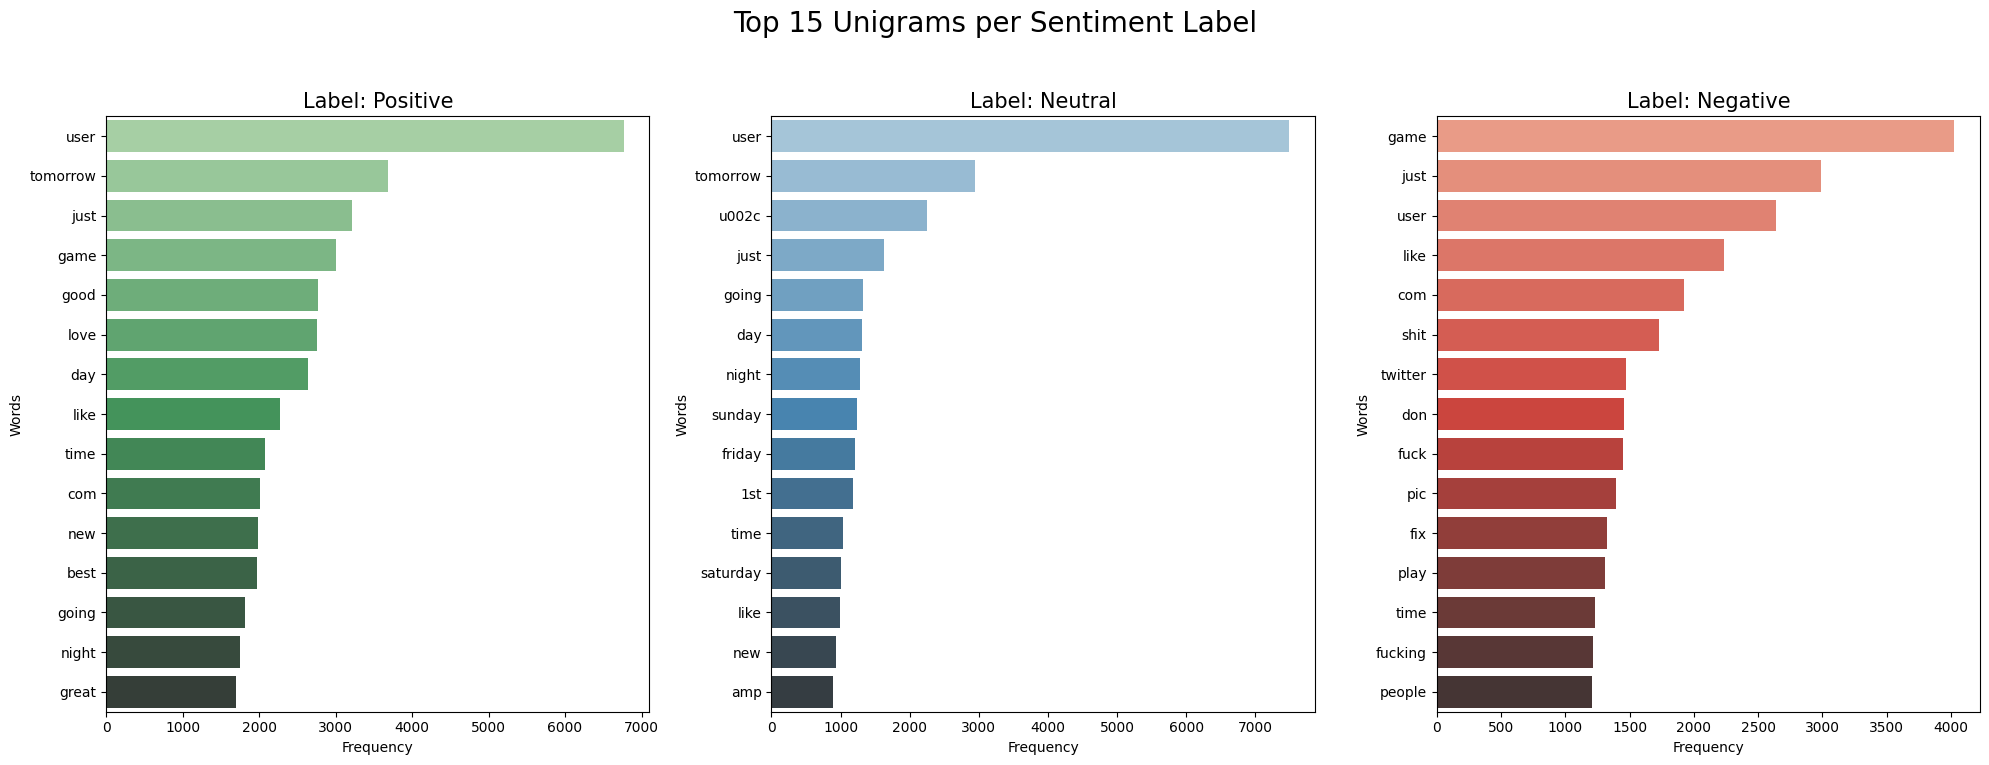

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=False)
fig.suptitle('Top 15 Unigrams per Sentiment Label', fontsize=20)

labels = ['Positive', 'Neutral', 'Negative']
colors = ['Greens_d', 'Blues_d', 'Reds_d']

for i, label in enumerate(labels):
    specific_label_text = df_train[df_train['label_text'] == label]['text']

    top_words = get_top_ngram(specific_label_text, n=15)
    words, counts = zip(*top_words)

    sns.barplot(x=list(counts), y=list(words), ax=axes[i], hue = list(words), palette=colors[i], legend = False)
    axes[i].set_title(f'Label: {label}', fontsize=15)
    axes[i].set_xlabel('Frequency')
    axes[i].set_ylabel('Words')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### E. Word Cloud

**Word Cloud:** Visualizing key terms to detect remaining noise or high-frequency stop words.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


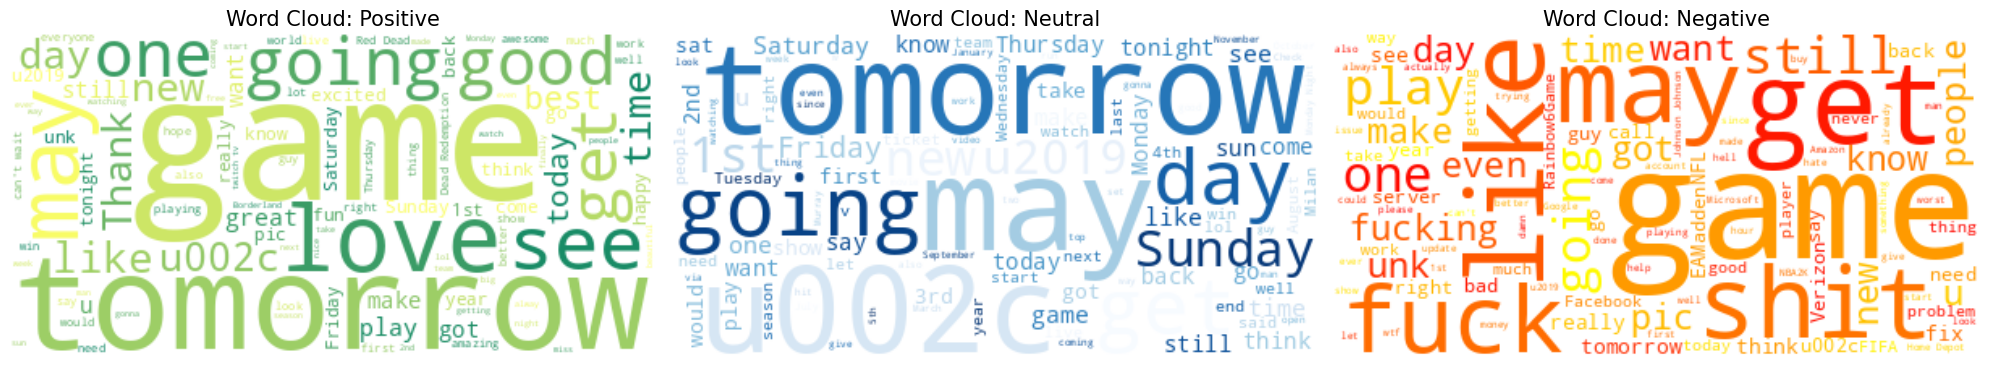

In [15]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('stopwords')

def generate_wordclouds(df):
    stop_words = set(stopwords.words('english'))
    custom_noise = {'user', 'http', 'rt', 'amp', 'qt', 'tweet', 'twitter'}
    stop_words.update(custom_noise)
    plt.figure(figsize=(20, 10))
    labels = ['Positive', 'Neutral', 'Negative']
    colors = ['summer', 'Blues', 'autumn']

    for i, label in enumerate(labels):
        text = " ".join(review for review in df[df['label_text'] == label].text)

        wordcloud = WordCloud(
            background_color="white",
            max_words=100,
            colormap=colors[i],
            stopwords=stop_words
        ).generate(text)

        plt.subplot(1, 3, i+1)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Word Cloud: {label}', fontsize=15)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

generate_wordclouds(df_train)

### F. Check Duplicates

**Check Duplicates:** Identifying and removing duplicate tweets within and across splits to prevent Data Leakage, ensuring the model generalizes rather than memorizing.

In [16]:
def check_and_remove_duplicates(df_train, df_val, df_test):
    print("--- Duplicates ---")
    print(f"Train duplicates: {df_train.duplicated(subset=['text']).sum()}")
    print(f"Val duplicates:   {df_val.duplicated(subset=['text']).sum()}")
    print(f"Test duplicates:  {df_test.duplicated(subset=['text']).sum()}")

    df_train = df_train.drop_duplicates(subset=['text']).reset_index(drop=True)
    df_val   = df_val.drop_duplicates(subset=['text']).reset_index(drop=True)
    df_test  = df_test.drop_duplicates(subset=['text']).reset_index(drop=True)

    leakage = df_test[df_test['text'].isin(df_train['text'])]
    print(f"\n Data Leakage: {len(leakage)}")

    if len(leakage) > 0:
        df_test = df_test[~df_test['text'].isin(df_train['text'])].reset_index(drop=True)
        print("Duplicates removed.")

    print("\n--- Size after remove duplicates ---")
    print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

    return df_train, df_val, df_test

df_train, df_val, df_test = check_and_remove_duplicates(df_train, df_val, df_test)

--- Duplicates ---
Train duplicates: 2763
Val duplicates:   1
Test duplicates:  0

 Data Leakage: 0

--- Size after remove duplicates ---
Train: 85865, Val: 2542, Test: 12284


## 4. Data preprocessing

Standardizing noisy Twitter text into a format suitable for Transformer models:

* **Lowercasing:** Converting all text to lowercase for uniformity.

* **Handle Mentions:** Normalizing user handles (e.g., `@someone`) to a generic `@user` token.

* **Handle URLs:** Normalizing links to a generic `http` token.

In [17]:
def preprocess(text):
    new_text = []
    for t in text.split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t.lower())
    return " ".join(new_text)

In [18]:
df_train["text"] = df_train["text"].apply(preprocess)
df_test["text"] = df_test["text"].apply(preprocess)
df_val["text"] = df_val["text"].apply(preprocess)

In [19]:
display(df_train.head())

,text,label_text,label,word_count
0,qt @user in the original draft of the 7th book...,Positive,2,18
1,ben smith / smith (concussion) remains out of ...,Neutral,1,14
2,sorry bout the stream last night i crashed out...,Neutral,1,24
3,chase headley's rbi double in the 8th inning o...,Neutral,1,23
4,@user alciato: bee will invest 150 million in ...,Positive,2,21


In [20]:
df_train['label'] = df_train['label'].astype(int)
df_val['label'] = df_val['label'].astype(int)
df_test['label'] = df_test['label'].astype(int)

dataset = DatasetDict({
    "train": Dataset.from_pandas(df_train[['text', 'label']]),
    "validation": Dataset.from_pandas(df_val[['text', 'label']]),
    "test": Dataset.from_pandas(df_test[['text', 'label']])
})

## 5. Tokenizations

**Model & Tokenizer Selection:** We utilize `twitter-roberta-base-sentiment-latest`, a RoBERTa-based model pre-trained on hundreds of millions of tweets. This ensures the model is well-acquainted with social media-specific linguistic patterns, emojis, and slang.

In [21]:
model_nm = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_nm)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=100)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Map:   0%|          | 0/85865 [00:00<?, ? examples/s]

Map:   0%|          | 0/2542 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

## 6. Training

**Training Configuration:**

* **Mixed Precision (FP16):** Enabled to optimize VRAM usage and accelerate training speed on compatible GPUs.

* **Evaluation Strategy:** Set to an "epoch" basis to closely monitor convergence and prevent overfitting.

* **Best Model Checkpointing:** The `load_best_model_at_end` parameter is used to ensure the final weights used for inference are those that achieved the highest accuracy on the validation set.

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(model_nm, num_labels=3)

total_steps = (len(tokenized_datasets["train"]) // 32) * 3
warmup_steps = int(0.1 * total_steps)

def compute_metrics(eval_pred):
    accuracy_metric = evaluate.load("accuracy")
    f1_metric = evaluate.load("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]

    return {"accuracy": acc, "f1": f1}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./twitter_sentiment_results",
    warmup_steps=warmup_steps,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,

    learning_rate=2e-5,
    weight_decay=0.01,
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,

    report_to="tensorboard",
    logging_steps=100,
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.409226,0.452750,0.793863,0.794103
2,0.298254,0.459213,0.813533,0.814053
3,0.204353,0.524687,0.808025,0.807816


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=8052, training_loss=0.327896896903336, metrics={'train_runtime': 1413.3189, 'train_samples_per_second': 182.262, 'train_steps_per_second': 5.697, 'total_flos': 1.3237636882743e+16, 'train_loss': 0.327896896903336, 'epoch': 3.0})

## 7. Test

Post-training, the model is subjected to a rigorous evaluation on the independent test set, which has been cleaned of duplicates during the EDA phase.

**Quantitative Metrics:** We calculate **Accuracy** and **Weighted F1-Score** to provide a balanced view of performance, especially given the slight class imbalance in the training data.

In [25]:
test_results = trainer.evaluate(tokenized_datasets["test"])
print(f"Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"F1 Score: {test_results['eval_f1']:.4f}")

Accuracy: 0.7108
F1 Score: 0.7102


**Qualitative Testing (Inference):** A custom inference function is implemented to test the model's behavior on raw, unseen strings, allowing for a quick sanity check of the sentiment predictions.

In [26]:
def predict_sentiment(text):
    inputs = tokenizer(preprocess(text), return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    predicted_class_id = logits.argmax().item()
    return ["Negative", "Neutral", "Positive"][predicted_class_id]

print(predict_sentiment("I love this project, it is so helpful!"))

Positive


## 8. Conclusion

The project successfully fine-tuned the **Twitter-RoBERTa-base** model on a consolidated dataset (TweetEval & Twitter Entity Sentiment). The training results are as follows:

* **Training Process:** The model showed strong convergence over 3 epochs, with the Training Loss decreasing from **0.409** to **0.204**.

* **Validation Results:** The peak performance on the validation set was achieved at Epoch 2, reaching an **Accuracy of 81.35%** and an **F1-Score of 81.41%**.

* **Final Test Performance:** On the independent test set, the model yielded a final **Accuracy of 71.08%** and an **F1-Score of 71.02%**.